In [2]:
import pandas as pd
import plotly.express as px
# import folium
import os
from scipy.stats import shapiro
import glob
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
from datetime import timedelta
import matplotlib.font_manager as fm
import matplotlib as mpl
from matplotlib import rc
import matplotlib.cm as cm
import numpy as np
import ast
import json
from matplotlib.ticker import FuncFormatter
import geopandas as gpd
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.expand_frame_repr', False)

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

from collections import Counter
# from kiwipiepy import Kiwi

mpl.rcParams.update(mpl.rcParamsDefault)

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_prop = fm.FontProperties(fname=font_path)
# , fontproperties=font_prop

from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
import os
os.environ["OMP_NUM_THREADS"] = "1"

import matplotlib.font_manager as fm
import platform

# Windows의 경우 맑은 고딕 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'

# 마이너스 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [3]:
merge = pd.read_csv('C:/Users/syc09/Desktop/codeit/문체부 공모전/munhwa/merged_final_please_df.csv')
merge.head()

,mountain_name,course_name,course_id,start_point_name,start_point_id,start_lat,start_lon,end_point_name,end_point_id,end_lat,end_lon,schedule,distance_km,duration_min,attraction_list,attraction_count,difficulty,sunset_summer,sunset_winter,shelter_count,dist_to_nearest_parking_km,walkable_to_public_transport,start_place_ID,start_dist_to_1_foods,start_dist_to_50_foods,start_dist_to_70_foods,start_dist_to_100_foods,start_dist_to_1_stays,start_dist_to_10_stays,start_dist_to_20_stays,start_dist_to_30_stays,end_place_ID,end_dist_to_1_foods,end_dist_to_50_foods,end_dist_to_70_foods,end_dist_to_100_foods,end_dist_to_1_stays,end_dist_to_10_stays,end_dist_to_20_stays,end_dist_to_30_stays
0,팔공산,수태골∼동봉,PG_01,수태골탐방지원센터,PG_ENT_01,35.993840,128.68139,동봉,PG_EXT_01,NaN,NaN,1,3.85,115,"수릉봉산계표석, 수태골폭포, 동봉, 동봉석조약사여래입상",4,2,19:46:00,17:22:00,0,0.143,1,PG_ENT_01,0.32,1.94,3.95,4.27,0.82,4.70,6.22,7.41,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,팔공산,진남문∼가산봉,PG_02,진남문(해원정사),PG_ENT_02,36.021210,128.59080,가산봉,PG_EXT_02,NaN,NaN,1,4.70,155,"진남문, 진천주사터(휴게정자), 복수초군락지, 가산산성, 가산봉",5,1,19:45:00,17:21:00,0,0.066,1,PG_ENT_02,0.59,1.53,1.92,2.53,1.28,2.70,5.47,9.02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,팔공산,치산지∼동봉,PG_03,치산지,PG_ENT_03,36.043130,128.71520,동봉,PG_EXT_01,NaN,NaN,1,5.60,190,"치산지, 치산계곡, 수도사, 공산폭포, 동봉",5,2,19:45:00,17:21:00,0,0.735,1,PG_ENT_03,0.55,6.14,6.26,6.49,1.76,6.60,8.77,10.66,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,팔공산,신일지∼은해봉,PG_04,신일지(은해사),PG_ENT_04,35.996310,128.78170,은해봉,PG_EXT_03,NaN,NaN,1,6.30,210,"치신일지, 은해사, 백흥암, 묘봉암, 은해봉",5,2,19:45:00,17:21:00,0,1.500,1,PG_ENT_04,1.48,3.37,3.79,4.49,2.69,7.92,10.07,12.43,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,팔공산,부인사∼서봉,PG_05,부인사,PG_ENT_05,35.994623,128.67395,서봉,PG_EXT_04,NaN,NaN,1,8.40,320,"부인사, 마당재, 벼락 맞은 나무, 서봉, 삼성암터",5,3,19:46:00,17:22:00,0,0.199,1,PG_ENT_05,0.40,2.28,3.55,3.98,1.49,4.89,5.89,6.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# 사분위수 기준값 구하기
q1 = merge['dist_to_nearest_parking_km'].quantile(0.25)
q2 = merge['dist_to_nearest_parking_km'].quantile(0.50)
q3 = merge['dist_to_nearest_parking_km'].quantile(0.75)

# 박스플롯 기준 상한 (이상치 기준값)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr

# 라벨링 함수 정의
def label_parking_dist(x):
    if x > upper_bound:
        return 4  # 이상치
    elif x <= q1:
        return 0
    elif x <= q2:
        return 1
    elif x <= q3:
        return 2
    else:
        return 3

# 적용
merge['parking_dist_label'] = merge['dist_to_nearest_parking_km'].apply(label_parking_dist)
merge.head()

,mountain_name,course_name,course_id,start_point_name,start_point_id,start_lat,start_lon,end_point_name,end_point_id,end_lat,end_lon,schedule,distance_km,duration_min,attraction_list,attraction_count,difficulty,sunset_summer,sunset_winter,shelter_count,dist_to_nearest_parking_km,walkable_to_public_transport,start_place_ID,start_dist_to_1_foods,start_dist_to_50_foods,start_dist_to_70_foods,start_dist_to_100_foods,start_dist_to_1_stays,start_dist_to_10_stays,start_dist_to_20_stays,start_dist_to_30_stays,end_place_ID,end_dist_to_1_foods,end_dist_to_50_foods,end_dist_to_70_foods,end_dist_to_100_foods,end_dist_to_1_stays,end_dist_to_10_stays,end_dist_to_20_stays,end_dist_to_30_stays,parking_dist_label
0,팔공산,수태골∼동봉,PG_01,수태골탐방지원센터,PG_ENT_01,35.993840,128.68139,동봉,PG_EXT_01,NaN,NaN,1,3.85,115,"수릉봉산계표석, 수태골폭포, 동봉, 동봉석조약사여래입상",4,2,19:46:00,17:22:00,0,0.143,1,PG_ENT_01,0.32,1.94,3.95,4.27,0.82,4.70,6.22,7.41,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
1,팔공산,진남문∼가산봉,PG_02,진남문(해원정사),PG_ENT_02,36.021210,128.59080,가산봉,PG_EXT_02,NaN,NaN,1,4.70,155,"진남문, 진천주사터(휴게정자), 복수초군락지, 가산산성, 가산봉",5,1,19:45:00,17:21:00,0,0.066,1,PG_ENT_02,0.59,1.53,1.92,2.53,1.28,2.70,5.47,9.02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,팔공산,치산지∼동봉,PG_03,치산지,PG_ENT_03,36.043130,128.71520,동봉,PG_EXT_01,NaN,NaN,1,5.60,190,"치산지, 치산계곡, 수도사, 공산폭포, 동봉",5,2,19:45:00,17:21:00,0,0.735,1,PG_ENT_03,0.55,6.14,6.26,6.49,1.76,6.60,8.77,10.66,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
3,팔공산,신일지∼은해봉,PG_04,신일지(은해사),PG_ENT_04,35.996310,128.78170,은해봉,PG_EXT_03,NaN,NaN,1,6.30,210,"치신일지, 은해사, 백흥암, 묘봉암, 은해봉",5,2,19:45:00,17:21:00,0,1.500,1,PG_ENT_04,1.48,3.37,3.79,4.49,2.69,7.92,10.07,12.43,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4
4,팔공산,부인사∼서봉,PG_05,부인사,PG_ENT_05,35.994623,128.67395,서봉,PG_EXT_04,NaN,NaN,1,8.40,320,"부인사, 마당재, 벼락 맞은 나무, 서봉, 삼성암터",5,3,19:46:00,17:22:00,0,0.199,1,PG_ENT_05,0.40,2.28,3.55,3.98,1.49,4.89,5.89,6.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1


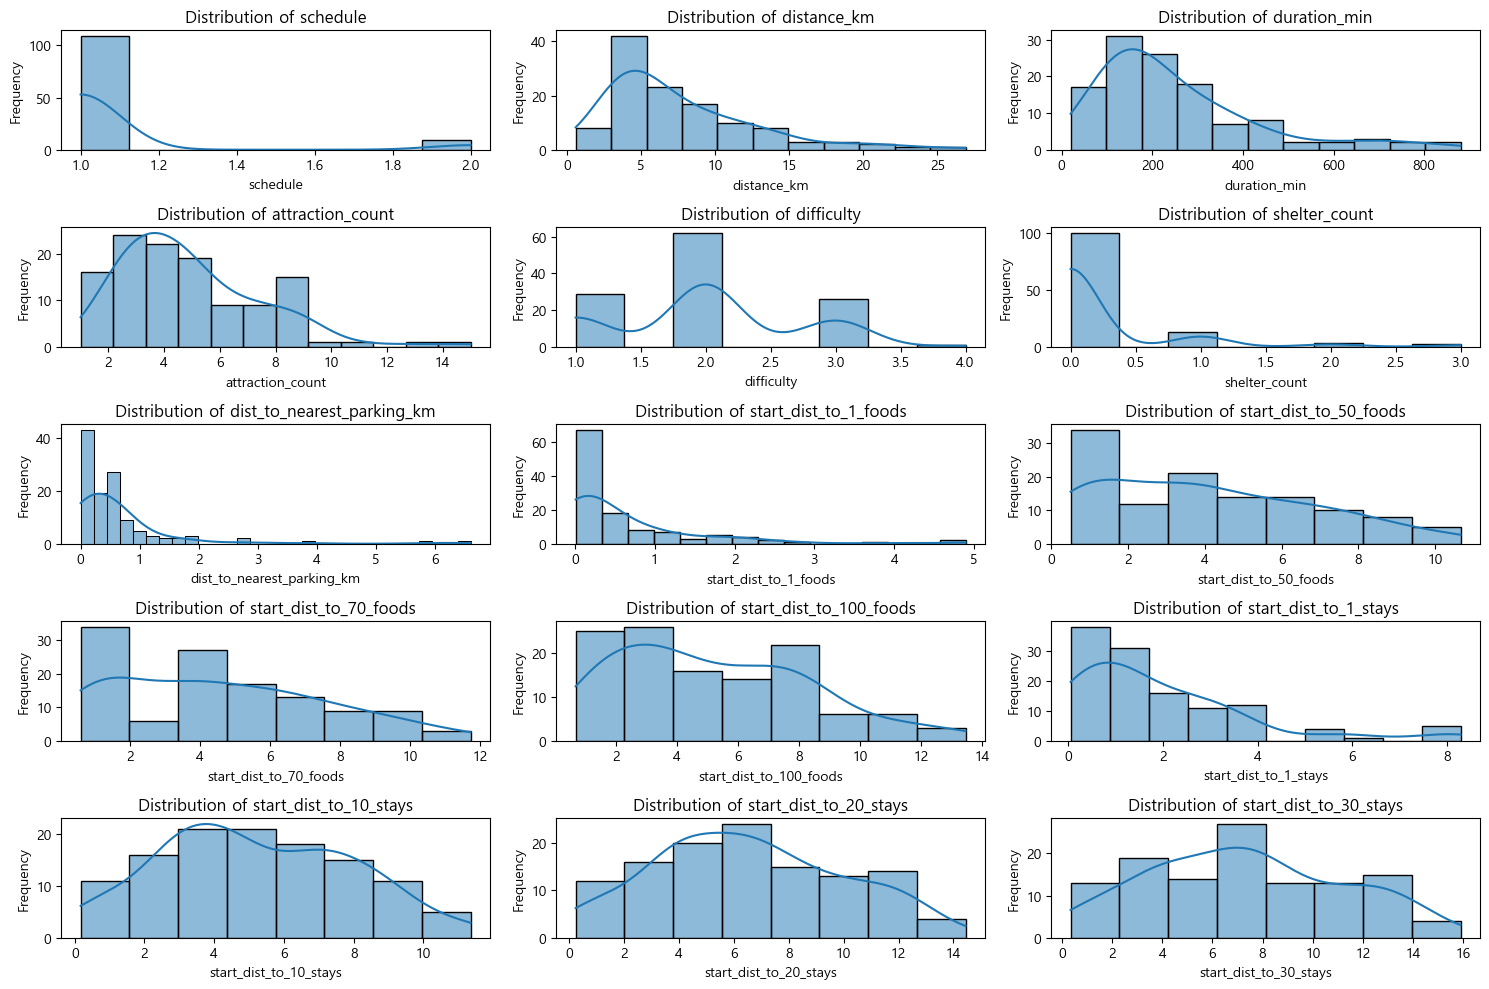

In [5]:
# 확인할 컬럼 목록
cols_to_check = [
    'schedule', 'distance_km', 'duration_min', 'attraction_count', 'difficulty',
    'shelter_count', 'dist_to_nearest_parking_km',
    'start_dist_to_1_foods', 'start_dist_to_50_foods', 'start_dist_to_70_foods', 'start_dist_to_100_foods',
    'start_dist_to_1_stays', 'start_dist_to_10_stays', 'start_dist_to_20_stays', 'start_dist_to_30_stays'
]

# 시각화: 분포 확인 (히스토그램)
plt.figure(figsize=(15, 10))
for i, col in enumerate(cols_to_check, 1):
    plt.subplot(5, 3, i)
    sns.histplot(merge[col].dropna(), kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [6]:
# Shapiro-Wilk 정규성 검정 수행
shapiro_results = []
for col in cols_to_check:
    data = merge[col].dropna()
    if len(data) < 3:  # shapiro는 최소 3개 이상 필요
        stat, p_value = None, None
    else:
        stat, p_value = shapiro(data.sample(n=min(len(data), 5000), random_state=42))  # 최대 5000개 샘플
    shapiro_results.append({
        'Column': col,
        'W-Statistic': stat,
        'p-value': p_value,
        'Normal? (p > 0.05)': p_value > 0.05 if p_value is not None else None
    })

shapiro_df = pd.DataFrame(shapiro_results)
shapiro_df

,Column,W-Statistic,p-value,Normal? (p > 0.05)
0,schedule,0.292078,2.318382e-21,False
1,distance_km,0.864071,5.222946e-09,False
2,duration_min,0.843849,8.009377e-10,False
3,attraction_count,0.906039,4.870953e-07,False
4,difficulty,0.822158,1.266870e-10,False
5,shelter_count,0.425786,1.800983e-19,False
6,dist_to_nearest_parking_km,0.567440,4.608947e-17,False
7,start_dist_to_1_foods,0.676356,8.931446e-15,False
8,start_dist_to_50_foods,0.937928,3.611933e-05,False
9,start_dist_to_70_foods,0.942354,7.141439e-05,False


In [7]:

# Windows MKL memory leak 방지
os.environ["OMP_NUM_THREADS"] = "1"

# 전체 사용 컬럼
cols = [
    'distance_km', 'attraction_count', 'difficulty', 'shelter_count',
    'walkable_to_public_transport', 'start_dist_to_1_foods',
    'start_dist_to_1_stays', 'start_dist_to_10_stays', 'parking_dist_label'
]

# 결측 제거
cluster_df_reduced = merge[cols].copy().dropna()

# ✅ 변수 분리
categorical_cols = ['walkable_to_public_transport']
numerical_cols = [col for col in cols if col not in categorical_cols]

# 스케일러 정의
scalers = {
    "StandardScaler": StandardScaler(),
    "RobustScaler": RobustScaler(),
    "MinMaxScaler": MinMaxScaler()
}

results = []

for scaler_name, scaler in scalers.items():
    # 연속형 변수 스케일링
    X_num_scaled = scaler.fit_transform(cluster_df_reduced[numerical_cols])
    
    # DataFrame으로 변환 후 범주형 변수 결합
    X_combined = pd.DataFrame(X_num_scaled, columns=numerical_cols, index=cluster_df_reduced.index)
    X_combined[categorical_cols] = cluster_df_reduced[categorical_cols]  # 원본값 그대로 추가
    
    X = X_combined.values

    # KMeans
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    kmeans_labels = kmeans.fit_predict(X)
    kmeans_score = silhouette_score(X, kmeans_labels)

    # DBSCAN
    dbscan = DBSCAN(eps=2, min_samples=5)
    dbscan_labels = dbscan.fit_predict(X)
    dbscan_score = silhouette_score(X, dbscan_labels) if len(set(dbscan_labels)) > 1 else -1

    # GMM
    gmm = GaussianMixture(n_components=3, random_state=42)
    gmm_labels = gmm.fit_predict(X)
    gmm_score = silhouette_score(X, gmm_labels)

    results += [
        {"Scaler": scaler_name, "Algorithm": "KMeans", "Silhouette Score": kmeans_score},
        {"Scaler": scaler_name, "Algorithm": "DBSCAN", "Silhouette Score": dbscan_score},
        {"Scaler": scaler_name, "Algorithm": "GMM", "Silhouette Score": gmm_score},
    ]

# 결과 정리 및 정렬
results_df = pd.DataFrame(results).sort_values(by="Silhouette Score", ascending=False)
print(results_df)

c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

           Scaler Algorithm  Silhouette Score
4    RobustScaler    DBSCAN          0.387704
3    RobustScaler    KMeans          0.260971
6    MinMaxScaler    KMeans          0.246567
1  StandardScaler    DBSCAN          0.245336
0  StandardScaler    KMeans          0.242791
5    RobustScaler       GMM          0.232718
2  StandardScaler       GMM          0.208460
8    MinMaxScaler       GMM          0.155426
7    MinMaxScaler    DBSCAN         -1.000000


c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [8]:
from sklearn.preprocessing import RobustScaler

# 사용할 컬럼
cols = ['distance_km', 'attraction_count', 'difficulty',
        'shelter_count', 'walkable_to_public_transport',
        'start_dist_to_1_foods', 'start_dist_to_1_stays',
        'start_dist_to_10_stays', 'parking_dist_label']

# 결측치 제거
X = merge[cols].dropna()

# walkable 제외하고 스케일링
scale_cols = [col for col in cols if col != 'walkable_to_public_transport']
scaler = RobustScaler()
X_scaled_part = scaler.fit_transform(X[scale_cols])

# 다시 합치기
X_final = pd.DataFrame(X_scaled_part, columns=scale_cols, index=X.index)
X_final['walkable_to_public_transport'] = X['walkable_to_public_transport']


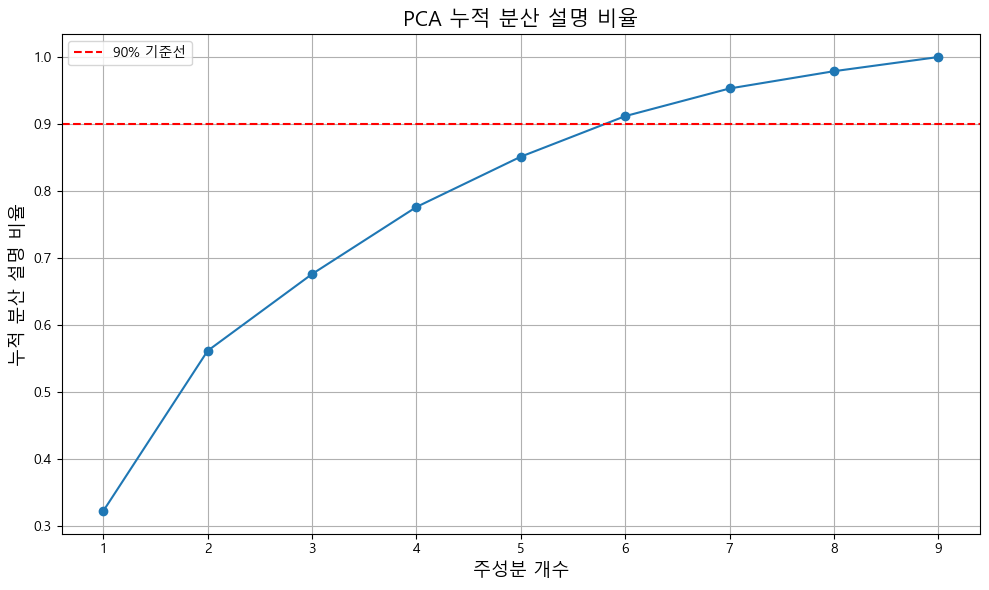

In [9]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# PCA 전체 적용 (모든 주성분)
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_final)  # X_final은 정규화 완료된 최종 입력

explained_var = pca_full.explained_variance_ratio_
cumulative_var = explained_var.cumsum()

# 누적 분산 시각화
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_var) + 1), cumulative_var, marker='o')
plt.axhline(y=0.9, color='r', linestyle='--', label='90% 기준선')
plt.xticks(range(1, len(cumulative_var) + 1))
plt.xlabel('주성분 개수', fontsize=13)
plt.ylabel('누적 분산 설명 비율', fontsize=13)
plt.title('PCA 누적 분산 설명 비율', fontsize=15)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


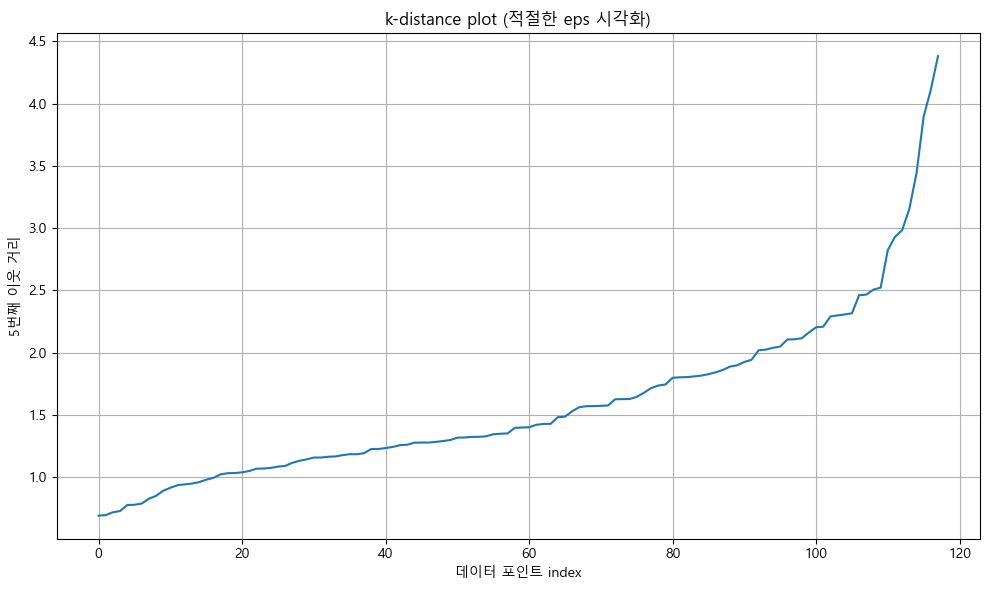

In [10]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

# 이미 정규화된 X_final 사용
min_samples = 5  # 보통 4~6 추천
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_final)
distances, indices = neighbors_fit.kneighbors(X_final)

# 각 포인트에서 min_samples번째 이웃까지 거리
k_distances = np.sort(distances[:, -1])

# 시각화
plt.figure(figsize=(10, 6))
plt.plot(k_distances)
plt.xlabel('데이터 포인트 index')
plt.ylabel(f'{min_samples}번째 이웃 거리')
plt.title('k-distance plot (적절한 eps 시각화)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [11]:
from sklearn.decomposition import PCA

# 주성분 2개 또는 4개 선택
pca = PCA(n_components=6)  # 또는 n_components=2
X_pca = pca.fit_transform(X_final)

# PCA 성분 영향도 확인
pca_components = pd.DataFrame(
    pca.components_, 
    columns=X_final.columns,
    index=[f'PC{i+1}' for i in range(pca.n_components_)]
).T

pca_components.sort_values(by='PC1', ascending=False)


,PC1,PC2,PC3,PC4,PC5,PC6
start_dist_to_1_foods,0.772710,0.010878,0.566780,-0.185518,0.156555,0.009080
start_dist_to_1_stays,0.536312,-0.095845,-0.524877,-0.071936,-0.253619,-0.017080
start_dist_to_10_stays,0.261808,0.053568,-0.539457,-0.047256,-0.098387,-0.193124
parking_dist_label,0.132928,-0.073713,0.207429,0.809499,-0.501652,-0.138558
distance_km,0.092518,0.658285,-0.081627,0.219780,0.128283,0.382778
difficulty,0.072615,0.395571,-0.116671,0.315810,0.544616,-0.495658
shelter_count,0.024846,0.305268,-0.023346,0.008638,-0.201750,0.569628
walkable_to_public_transport,-0.051579,-0.026093,0.127351,-0.003552,-0.032373,-0.197766
attraction_count,-0.109391,0.546541,0.179402,-0.393396,-0.543156,-0.432836


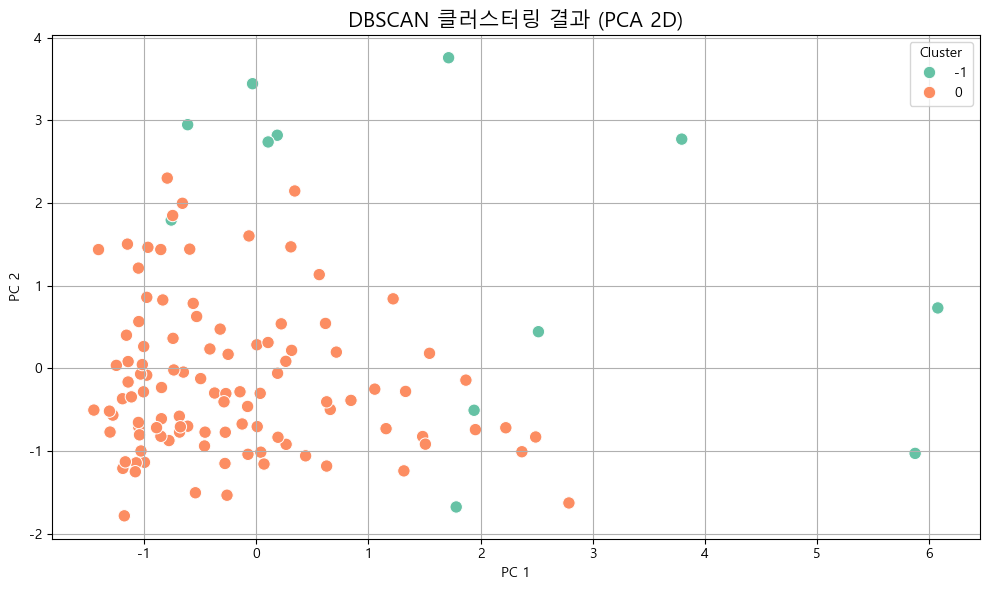

In [12]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# PCA 2D 변환
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_final)

# DBSCAN 클러스터링 수행
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=2.0, min_samples=5)
labels = dbscan.fit_predict(X_final)

# 시각화
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=X_pca_2d[:, 0], y=X_pca_2d[:, 1],
    hue=labels, palette='Set2', s=80
)
plt.title("DBSCAN 클러스터링 결과 (PCA 2D)", fontsize=15)
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.legend(title="Cluster")
plt.grid(True)
plt.tight_layout()
plt.show()


In [13]:
# 클러스터 정보 포함
cluster_df = X.copy()
cluster_df['cluster'] = labels

# 클러스터별 평균값 비교
cluster_summary = cluster_df.groupby('cluster').mean().round(2)
cluster_summary


,distance_km,attraction_count,difficulty,shelter_count,walkable_to_public_transport,start_dist_to_1_foods,start_dist_to_1_stays,start_dist_to_10_stays,parking_dist_label
cluster,,,,,,,,,
-1,15.18,6.25,2.50,1.08,0.67,1.85,3.74,7.14,1.50
0,6.72,4.75,1.93,0.11,0.85,0.49,1.72,4.97,1.58


In [14]:
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import DBSCAN
import pandas as pd

# 사용할 컬럼
cols = ['distance_km', 'attraction_count', 'difficulty',
        'shelter_count', 'walkable_to_public_transport',
        'start_dist_to_1_foods', 'start_dist_to_1_stays',
        'start_dist_to_10_stays', 'parking_dist_label']

# 결측치 제거
X = merge[cols].dropna()

# walkable 제외하고 스케일링
scale_cols = [col for col in cols if col != 'walkable_to_public_transport']
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X[scale_cols])

# 스케일된 값 + 범주형 다시 합치기
X_final = pd.DataFrame(X_scaled, columns=scale_cols, index=X.index)
X_final['walkable_to_public_transport'] = X['walkable_to_public_transport']

from sklearn.cluster import DBSCAN

# DBSCAN 적용 (eps는 적절한 값으로)
dbscan = DBSCAN(eps=2.0, min_samples=5)
labels = dbscan.fit_predict(X_final)

# 클러스터 수 및 잡음 확인
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print(f"📌 유효 클러스터 수: {n_clusters}")
print(f"📌 잡음 포인트 수 (Noise): {n_noise}")

# 라벨을 원본 데이터프레임에 붙이기
X_labeled = X.copy()  # 스케일링 전 원본
X_labeled['cluster'] = labels

# 잡음 제외한 클러스터별 개수
cluster_counts = X_labeled[X_labeled['cluster'] != -1]['cluster'].value_counts().sort_index()
print("\n📊 클러스터별 데이터 수:")
print(cluster_counts)

# 클러스터별 평균값
cluster_means = X_labeled[X_labeled['cluster'] != -1].groupby('cluster').mean()
print("\n📊 클러스터별 평균값:")
print(cluster_means)


📌 유효 클러스터 수: 1
📌 잡음 포인트 수 (Noise): 12

📊 클러스터별 데이터 수:
cluster
0    106
Name: count, dtype: int64

📊 클러스터별 평균값:
         distance_km  attraction_count  difficulty  shelter_count  walkable_to_public_transport  start_dist_to_1_foods  start_dist_to_1_stays  start_dist_to_10_stays  parking_dist_label
cluster                                                                                                                                                                                  
0           6.721698          4.754717    1.933962       0.113208                      0.849057               0.488944               1.722091                 4.96624            1.584906


In [15]:
# 그리드서치
from sklearn.metrics import silhouette_score
from sklearn.cluster import DBSCAN
import numpy as np
import pandas as pd

# 대상 데이터: X_final
X = X_final.copy()

# 탐색할 eps, min_samples 범위 설정
eps_values = np.arange(0.5, 5.1, 0.1)
min_samples_values = range(3, 11)

results = []

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X)

        # 유효 클러스터 수 계산
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)

        # 클러스터 수가 2개 이상일 때만 실루엣 점수 계산
        if n_clusters > 1:
            score = silhouette_score(X, labels)
        else:
            score = -1  # 의미 없는 점수 처리

        results.append({
            "eps": eps,
            "min_samples": min_samples,
            "n_clusters": n_clusters,
            "n_noise": n_noise,
            "silhouette_score": score
        })

# 결과 정리
results_df = pd.DataFrame(results).sort_values(by="silhouette_score", ascending=False)

results_df.head()


,eps,min_samples,n_clusters,n_noise,silhouette_score
104,1.8,3,2,12,0.291137
105,1.8,4,2,13,0.288330
96,1.7,3,3,18,0.233846
88,1.6,3,3,25,0.208794
72,1.4,3,3,37,0.123834


In [16]:
len(merge)

118

In [17]:
# 최적 파라미터로 DBSCAN 재실행
from sklearn.cluster import DBSCAN

best_dbscan = DBSCAN(eps=2.1, min_samples=3)
X_final['cluster'] = best_dbscan.fit_predict(X_final)

# 클러스터 수 확인
n_clusters = len(set(X_final['cluster'])) - (1 if -1 in X_final['cluster'].values else 0)
n_noise = list(X_final['cluster']).count(-1)

print(f"📌 유효 클러스터 수: {n_clusters}")
print(f"📌 잡음 포인트 수: {n_noise}")

# 클러스터별 데이터 수 확인
print("\n📊 클러스터별 데이터 수:")
print(X_final['cluster'].value_counts().sort_index())

# 클러스터별 평균값 확인
print("\n📊 클러스터별 평균값:")
print(X_final.groupby('cluster').mean())


📌 유효 클러스터 수: 1
📌 잡음 포인트 수: 8

📊 클러스터별 데이터 수:
cluster
-1      8
 0    110
Name: count, dtype: int64

📊 클러스터별 평균값:
         distance_km  attraction_count  difficulty  shelter_count  start_dist_to_1_foods  start_dist_to_1_stays  start_dist_to_10_stays  parking_dist_label  walkable_to_public_transport
cluster                                                                                                                                                                                  
-1          2.046122          1.166667    0.875000       1.375000               2.362200               1.263190                0.357070            0.357143                      0.750000
 0          0.171832          0.239394   -0.072727       0.127273               0.403021               0.274156                0.092871            0.327273                      0.836364


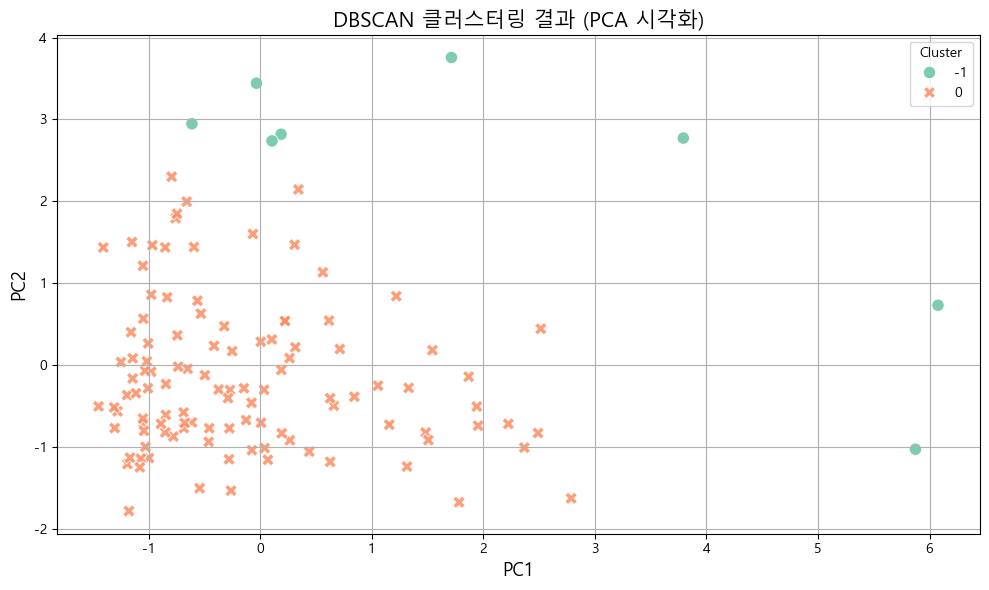

In [18]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# PCA로 2차원 축소
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_final.drop(columns=['cluster']))

# 클러스터 레이블과 결합
X_plot = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
X_plot['cluster'] = X_final['cluster'].values

# 시각화
plt.figure(figsize=(10, 6))
palette = sns.color_palette('Set2', n_colors=len(X_plot['cluster'].unique()))

sns.scatterplot(
    data=X_plot,
    x='PC1', y='PC2',
    hue='cluster',
    palette=palette,
    style='cluster',  # noise (-1)도 구분
    s=80,
    alpha=0.85
)

plt.title('DBSCAN 클러스터링 결과 (PCA 시각화)', fontsize=15)
plt.xlabel('PC1', fontsize=13)
plt.ylabel('PC2', fontsize=13)
plt.legend(title='Cluster')
plt.grid(True)
plt.tight_layout()
plt.show()


#### kmeans로 다시

c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

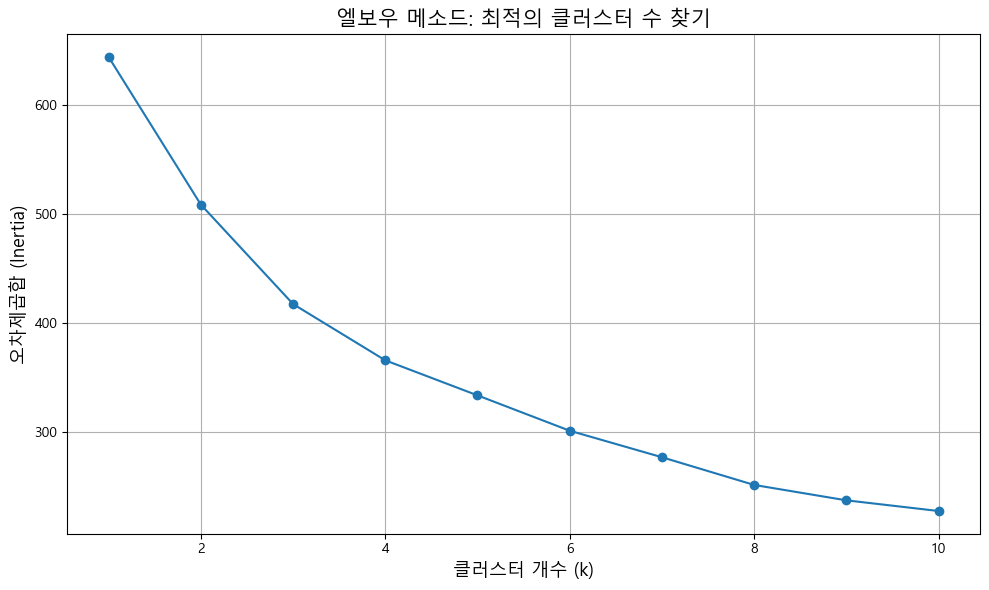

In [19]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# inertia 저장용 리스트
inertia_list = []
K_range = range(1, 11)  # 클러스터 개수 1~10까지 테스트

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_final)
    inertia_list.append(kmeans.inertia_)

# 시각화
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia_list, marker='o')
plt.xlabel('클러스터 개수 (k)', fontsize=13)
plt.ylabel('오차제곱합 (Inertia)', fontsize=13)
plt.title('엘보우 메소드: 최적의 클러스터 수 찾기', fontsize=15)
plt.grid(True)
plt.tight_layout()
plt.show()


In [20]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
X_final['cluster'] = kmeans.fit_predict(X_final)

# 클러스터별 데이터 수
print("📊 클러스터별 데이터 수:")
print(X_final['cluster'].value_counts().sort_index())

# 클러스터별 평균값
print("\n📊 클러스터별 평균값:")
print(X_final.groupby('cluster').mean())


📊 클러스터별 데이터 수:
cluster
0    23
1    22
2    73
Name: count, dtype: int64

📊 클러스터별 평균값:
         distance_km  attraction_count  difficulty  shelter_count  start_dist_to_1_foods  start_dist_to_1_stays  start_dist_to_10_stays  parking_dist_label  walkable_to_public_transport
cluster                                                                                                                                                                                  
0           0.291678         -0.144928   -0.043478       0.086957               2.013642               1.660633                0.767367            0.571429                      0.608696
1           1.479703          1.409091    0.636364       0.772727               0.154938               0.061679                0.228872            0.025974                      0.772727
2          -0.054680          0.109589   -0.191781       0.082192               0.185034               0.009743               -0.131674            0.344423              

c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


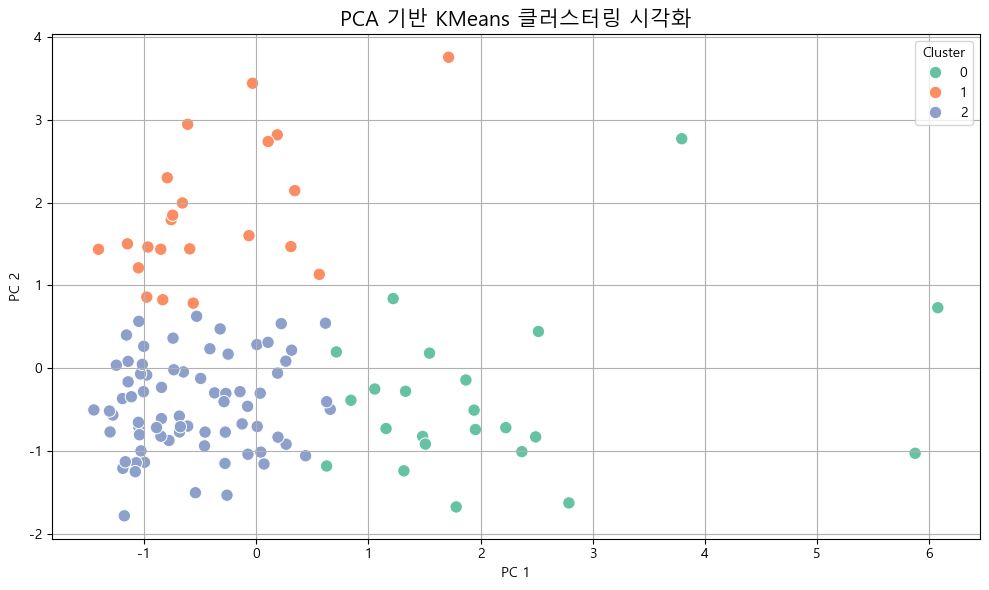

In [23]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# 2차원 PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_final.drop('cluster', axis=1))

# 시각화
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1],
                hue=X_final['cluster'], palette='Set2', s=80)
plt.title("PCA 기반 KMeans 클러스터링 시각화", fontsize=15)
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.legend(title="Cluster")
plt.grid(True)
plt.tight_layout()
plt.show()


In [24]:
from sklearn.cluster import KMeans

# 클러스터링 (k=3 기준)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_final)  # X_final은 정규화된 최종 데이터

# 클러스터 컬럼 추가
cluster_df_reduced = X_final.copy()  # 또는 merge[cols].dropna().copy() 형태
cluster_df_reduced['cluster'] = cluster_labels

# merge와 인덱스 일치 확인 (안 맞으면 join 대신 merge)
merge_with_cluster = merge.loc[cluster_df_reduced.index].copy()
merge_with_cluster['cluster'] = cluster_labels

# 클러스터별 course_name 출력
for i in sorted(merge_with_cluster['cluster'].dropna().unique()):
    print(f"\n📌 클러스터 {int(i)}에 속한 코스 목록:")
    print(merge_with_cluster[merge_with_cluster['cluster'] == i]['course_name'].tolist())



📌 클러스터 0에 속한 코스 목록:
['수태골∼동봉', '진남문∼가산봉', '치산지∼동봉', '부인사∼서봉', '오도암∼비로봉', '탑골∼동봉', '파계사∼파계재', '관암사∼관봉', '동학사 1코스 (편도)', '갑사 1코스 (편도)', '신원사 1코스 (편도)', '수통골 1코스 (편도)', '수통골 2코스 (종주)', '천정코스', '구룡계곡코스', '삼신봉코스', '만복대코스', '화엄계곡코스', '피아골코스', '불일폭포코스', '백무동코스', '노고단코스', '칠보산코스', '장각동코스', '신선대2코스', '신선대1코스', '문장대2코스', '문장대1코스', '문장대코스', '묘봉코스', '백악산코스', '세조길코스', '불목이옛길', '북한산성코스', '대남문코스', '사패산코스', '오봉코스', '우이암코스', '망월사_포대_회룡코스', '신선대코스', '백운대코스', '사모바위코스', '비봉코스', '보국문코스', '대동문코스', '소귀천코스', '용소폭포코스', '울산바위코스', '비룡폭포(토왕폭전망대)코스', '금강굴코스', '양폭코스', '남교리코스', '대청봉코스(오색)', '향적봉 2코스', '향적봉 1코스', '서창코스', '치목코스', '신풍령코스', '구천동 어사길 코스', '금대~남대봉', '행구동~향로봉', '성남~남대봉', '부곡~곧은재~비로봉', '구룡~세렴폭포', '구룡~비로봉', '황골~비로봉', '부곡~곧은재~비로봉', '금대~영원산성~남대봉', '부곡~큰무레골~비로봉', '새인봉 - 입석대 코스', '늦재 - 옛길 코스', '당산나무 코스', '도원마을 - 규봉 코스']

📌 클러스터 1에 속한 코스 목록:
['신일지∼은해봉', '정령치_바래봉코스', '반야봉코스', '대야산코스', '옥녀봉코스', '두로봉코스', '동대산코스', '상왕봉코스', '비로봉코스', '선재길코스', '계방산1코스', '계방산2코스', '백담사코스', '수렴동코스', '대승폭포코스', '대청봉코스(한계령)', '남덕유산코스', '삿갓재

c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [25]:
merge_with_cluster.head()

,mountain_name,course_name,course_id,start_point_name,start_point_id,start_lat,start_lon,end_point_name,end_point_id,end_lat,end_lon,schedule,distance_km,duration_min,attraction_list,attraction_count,difficulty,sunset_summer,sunset_winter,shelter_count,dist_to_nearest_parking_km,walkable_to_public_transport,start_place_ID,start_dist_to_1_foods,start_dist_to_50_foods,start_dist_to_70_foods,start_dist_to_100_foods,start_dist_to_1_stays,start_dist_to_10_stays,start_dist_to_20_stays,start_dist_to_30_stays,end_place_ID,end_dist_to_1_foods,end_dist_to_50_foods,end_dist_to_70_foods,end_dist_to_100_foods,end_dist_to_1_stays,end_dist_to_10_stays,end_dist_to_20_stays,end_dist_to_30_stays,parking_dist_label,cluster
0,팔공산,수태골∼동봉,PG_01,수태골탐방지원센터,PG_ENT_01,35.993840,128.68139,동봉,PG_EXT_01,NaN,NaN,1,3.85,115,"수릉봉산계표석, 수태골폭포, 동봉, 동봉석조약사여래입상",4,2,19:46:00,17:22:00,0,0.143,1,PG_ENT_01,0.32,1.94,3.95,4.27,0.82,4.70,6.22,7.41,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0
1,팔공산,진남문∼가산봉,PG_02,진남문(해원정사),PG_ENT_02,36.021210,128.59080,가산봉,PG_EXT_02,NaN,NaN,1,4.70,155,"진남문, 진천주사터(휴게정자), 복수초군락지, 가산산성, 가산봉",5,1,19:45:00,17:21:00,0,0.066,1,PG_ENT_02,0.59,1.53,1.92,2.53,1.28,2.70,5.47,9.02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
2,팔공산,치산지∼동봉,PG_03,치산지,PG_ENT_03,36.043130,128.71520,동봉,PG_EXT_01,NaN,NaN,1,5.60,190,"치산지, 치산계곡, 수도사, 공산폭포, 동봉",5,2,19:45:00,17:21:00,0,0.735,1,PG_ENT_03,0.55,6.14,6.26,6.49,1.76,6.60,8.77,10.66,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,0
3,팔공산,신일지∼은해봉,PG_04,신일지(은해사),PG_ENT_04,35.996310,128.78170,은해봉,PG_EXT_03,NaN,NaN,1,6.30,210,"치신일지, 은해사, 백흥암, 묘봉암, 은해봉",5,2,19:45:00,17:21:00,0,1.500,1,PG_ENT_04,1.48,3.37,3.79,4.49,2.69,7.92,10.07,12.43,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,1
4,팔공산,부인사∼서봉,PG_05,부인사,PG_ENT_05,35.994623,128.67395,서봉,PG_EXT_04,NaN,NaN,1,8.40,320,"부인사, 마당재, 벼락 맞은 나무, 서봉, 삼성암터",5,3,19:46:00,17:22:00,0,0.199,1,PG_ENT_05,0.40,2.28,3.55,3.98,1.49,4.89,5.89,6.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0


In [34]:
merge_with_cluster[merge_with_cluster['mountain_name'] == '치악산']

,mountain_name,course_name,course_id,start_point_name,start_point_id,start_lat,start_lon,end_point_name,end_point_id,end_lat,end_lon,schedule,distance_km,duration_min,attraction_list,attraction_count,difficulty,sunset_summer,sunset_winter,shelter_count,dist_to_nearest_parking_km,walkable_to_public_transport,start_place_ID,start_dist_to_1_foods,start_dist_to_50_foods,start_dist_to_70_foods,start_dist_to_100_foods,start_dist_to_1_stays,start_dist_to_10_stays,start_dist_to_20_stays,start_dist_to_30_stays,end_place_ID,end_dist_to_1_foods,end_dist_to_50_foods,end_dist_to_70_foods,end_dist_to_100_foods,end_dist_to_1_stays,end_dist_to_10_stays,end_dist_to_20_stays,end_dist_to_30_stays,parking_dist_label,cluster
100,치악산,금대~남대봉,CA_01,금대분소,CA_ENT_01,37.293013,128.017735,남대봉,CA_EXT_01,NaN,NaN,1,5.2,160,"금대에코힐링캠핑장, 자연생태 학습장인 자연관찰로, 영원사, 아들바위, 상원사, 광배",6,3,20:23,17:49,0,0.000,1,CA_ENT_01,0.067782,2.089425,2.162075,2.398516,0.115204,4.738358,6.312790,7.041838,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
101,치악산,행구동~향로봉,CA_02,행구탐방지원센터,CA_ENT_02,37.333289,128.014485,향로봉,CA_EXT_02,NaN,NaN,1,2.8,90,"보문사, 청석탑",2,1,20:23,17:49,0,0.267,1,CA_ENT_02,0.481558,1.299074,1.355838,1.431669,1.366990,2.621454,3.710320,5.319938,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0
102,치악산,성남~남대봉,CA_03,성남탐방지원센터,CA_ENT_03,37.280921,128.085242,남대봉,CA_EXT_01,NaN,NaN,1,5.9,150,"성황림, 대웅종, 상원사 동종, 상원사 광배, 삼층석탑",5,2,20:22,17:49,0,0.088,1,CA_ENT_03,0.037183,4.333486,4.710173,5.355102,0.177027,7.313483,9.813451,10.105024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
103,치악산,부곡~곧은재~비로봉,CA_04,부곡탐방지원센터,CA_ENT_04,37.333163,128.074154,비로봉,CA_EXT_03,NaN,NaN,1,8.9,180,"태종대, 노고소",2,2,20:23,17:49,0,0.673,1,CA_ENT_04,0.944477,5.674893,5.769193,5.920656,2.127666,6.502721,7.819823,8.530301,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,0
104,치악산,구룡~세렴폭포,CA_05,구룡탐방지원센터,CA_ENT_05,37.414398,128.050061,세렴폭포,CA_EXT_04,NaN,NaN,1,3.0,90,"황장금표, 구룡사, 용소",3,1,20:23,17:49,0,0.066,1,CA_ENT_05,0.071151,1.643136,2.226294,2.576248,1.157294,2.922374,6.103692,7.772196,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
105,치악산,구룡~비로봉,CA_06,구룡문화재매표소,CA_ENT_06,37.399761,128.050029,비로봉,CA_EXT_03,NaN,NaN,1,5.7,210,"황장금, 구룡사, 용소, 사다리병장, 비로봉",5,3,20:23,17:49,0,0.612,1,CA_ENT_06,0.683611,3.202862,3.440912,4.075258,0.663585,4.468481,5.797669,7.000730,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,0
106,치악산,구룡~향로봉~성남,CA_07,구룡탐방지원센터,CA_ENT_05,37.414398,128.050061,성남탐방지원센터,CA_ENT_03,37.280921,128.085242,1,21.4,600,"황장금, 구룡사, 용소, 사다리병장, 비로봉, 상원사 쌍탑 및 동종, 천연기념물 제...",7,3,20:23,17:49,0,0.066,1,CA_ENT_05,0.071151,1.643136,2.226294,2.576248,1.157294,2.922374,6.103692,7.772196,CA_ENT_03,13.752468,92.638606,103.018647,115.21785,0.177027,7.313483,9.813451,10.105024,0,2
107,치악산,황골~비로봉,CA_08,황골탐방지원센터,CA_ENT_07,37.360152,128.022102,비로봉,CA_EXT_03,NaN,NaN,1,4.1,150,"입석사, 흥양리마애불좌상, 입석대",3,2,20:23,17:49,0,0.038,1,CA_ENT_07,0.584400,1.358035,1.438117,1.619598,0.573101,2.414788,4.901441,5.905806,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
108,치악산,부곡~곧은재~비로봉,CA_09,부곡탐방지원센터,CA_ENT_04,37.333163,128.074154,곧은재,CA_EXT_05,NaN,NaN,1,4.1,60,"태종대, 부곡계곡, 부곡폭포, 곧은재",4,1,20:23,17:49,0,0.673,1,CA_ENT_04,0.944477,5.674893,5.769193,5.920656,2.127666,6.502721,7.819823,8.530301,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,0
109,치악산,금대~영원산성~남대봉,CA_10,금대분소,CA_ENT_01,37.293013,128.017735,남대봉,CA_EXT_01,NaN,NaN,1,5.6,180,"금대에코힐링캠핑, 부곡계곡",2,3,20:23,17:49,0,0.000,1,CA_ENT_01,0.067782,2.089425,2.162075,2.398516,0.115204,4.738358,6.312790,7.041838,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0


In [26]:
len(merge)

118

In [27]:
len(merge_with_cluster)

118

In [28]:
# 1. KMeans 클러스터링 (기준: X_final)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
X_final['cluster'] = kmeans.fit_predict(X_final)

# 2. merge에서 X_final과 동일한 인덱스만 선택
merge_with_cluster = merge.loc[X_final.index].copy()
merge_with_cluster['cluster'] = X_final['cluster']

# 3. mountain_name별 클러스터 분포 집계
cluster_distribution = (
    merge_with_cluster
    .groupby(['mountain_name', 'cluster'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

# 4. 열 이름 정리
cluster_distribution.columns.name = None
cluster_distribution.columns = ['mountain_name'] + [f'cluster_{i}' for i in range(cluster_distribution.shape[1] - 1)]

# 5. 출력
cluster_distribution

c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,mountain_name,cluster_0,cluster_1,cluster_2
0,계룡산,6,0,3
1,덕유산,6,6,1
2,무등산,4,1,2
3,북한산,13,0,0
4,설악산,7,4,3
5,속리산,11,2,5
6,오대산,0,7,1
7,지리산,8,2,6
8,치악산,10,0,1
9,팔공산,8,1,0


In [29]:
cluster_distribution.cluster_0.sum(), cluster_distribution.cluster_1.sum(), cluster_distribution.cluster_2.sum()

(73, 23, 22)

📊 클러스터별 데이터 수:
- cluster
- 0    23
- 1    22
- 2    73

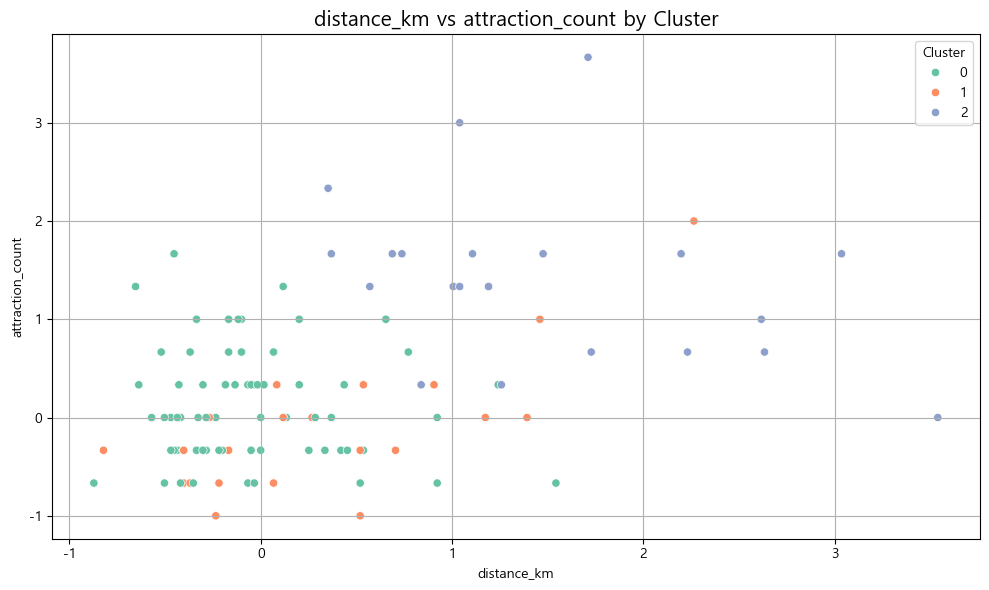

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# 예시: distance_km vs attraction_count
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=X_final,
    x='distance_km',
    y='attraction_count',
    hue='cluster',
    palette='Set2'
)
plt.title("distance_km vs attraction_count by Cluster", fontsize=15)
plt.xlabel("distance_km")
plt.ylabel("attraction_count")
plt.legend(title="Cluster")
plt.grid(True)
plt.tight_layout()
plt.show()


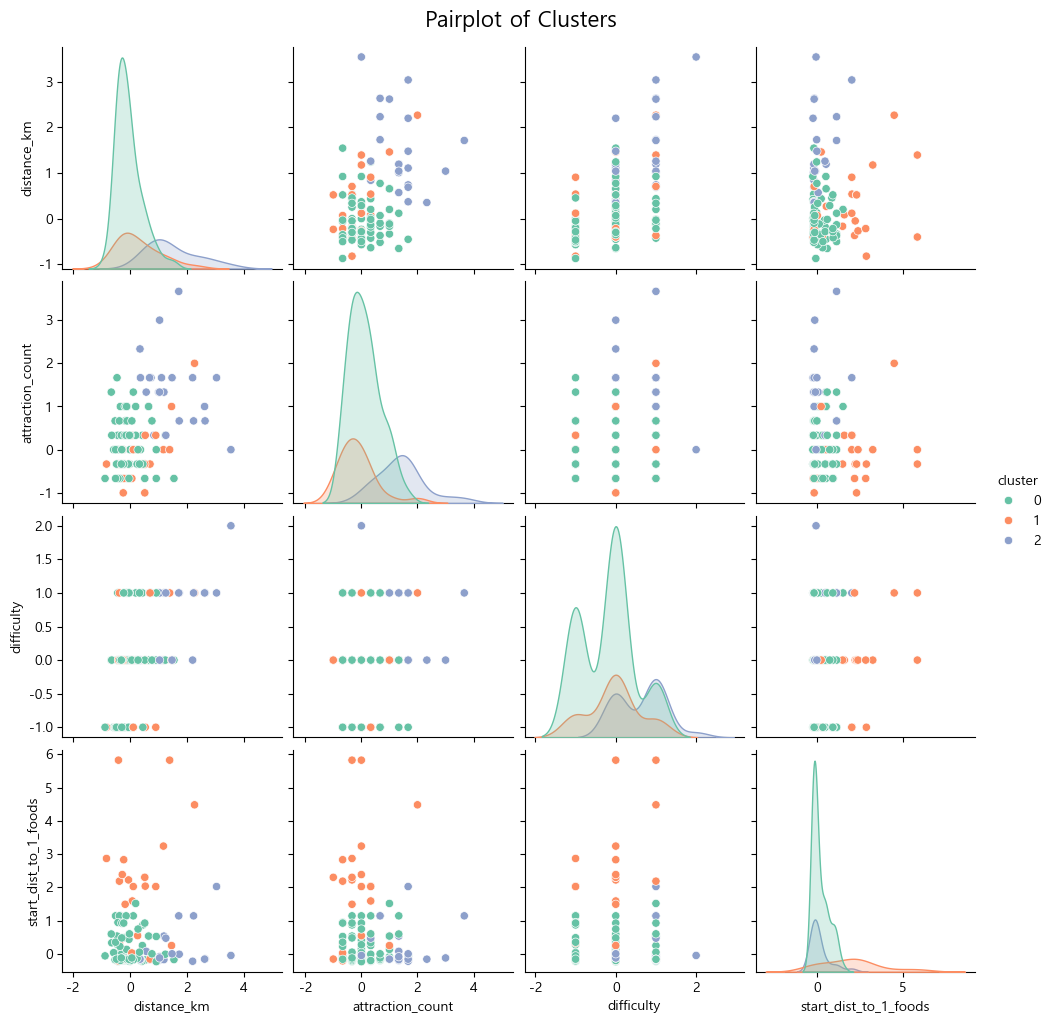

In [31]:
import seaborn as sns

cols = ['distance_km', 'attraction_count', 'difficulty', 'start_dist_to_1_foods']
sns.pairplot(X_final[cols + ['cluster']], hue='cluster', palette='Set2')
plt.suptitle("Pairplot of Clusters", y=1.02, fontsize=16)
plt.show()


C:\Users\syc09\AppData\Local\Temp\ipykernel_25864\3427243062.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=X_final, x='cluster', y='distance_km', palette='Set2')


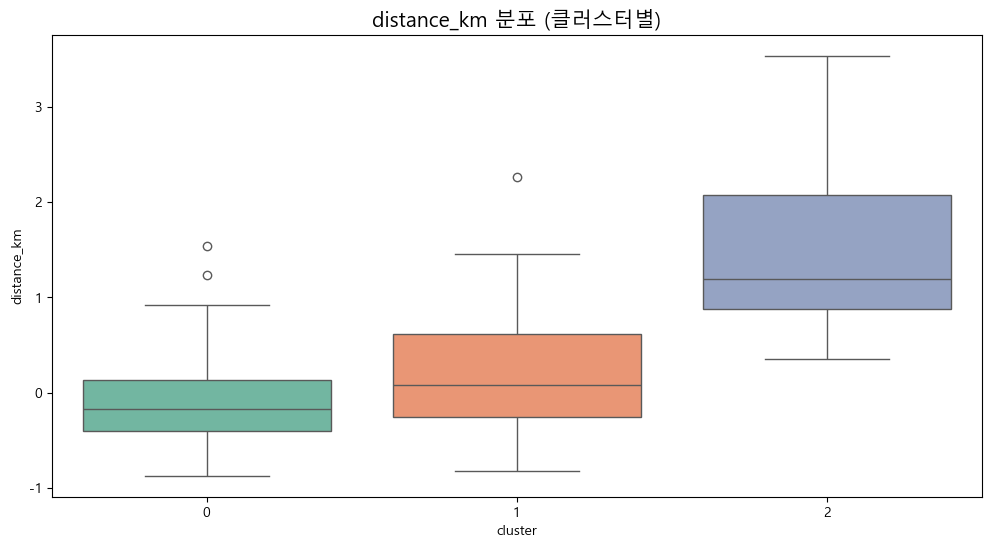

In [32]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=X_final, x='cluster', y='distance_km', palette='Set2')
plt.title("distance_km 분포 (클러스터별)", fontsize=15)
plt.show()


C:\Users\syc09\AppData\Local\Temp\ipykernel_25864\2862513024.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=X_final, x='cluster', y=col, palette='Set2')


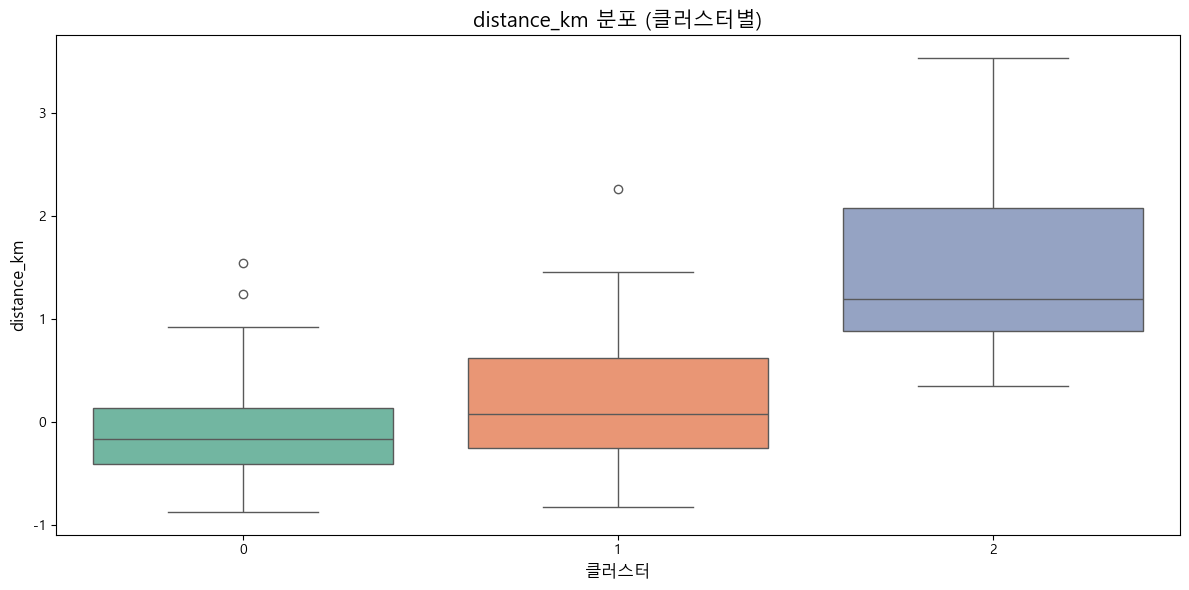

C:\Users\syc09\AppData\Local\Temp\ipykernel_25864\2862513024.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=X_final, x='cluster', y=col, palette='Set2')


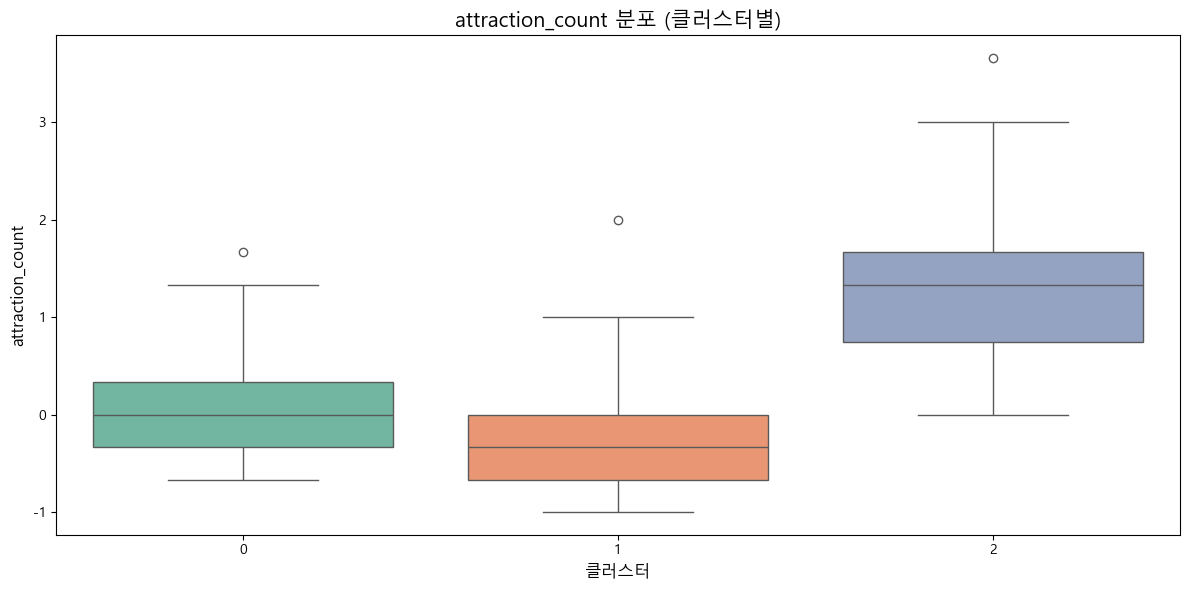

C:\Users\syc09\AppData\Local\Temp\ipykernel_25864\2862513024.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=X_final, x='cluster', y=col, palette='Set2')


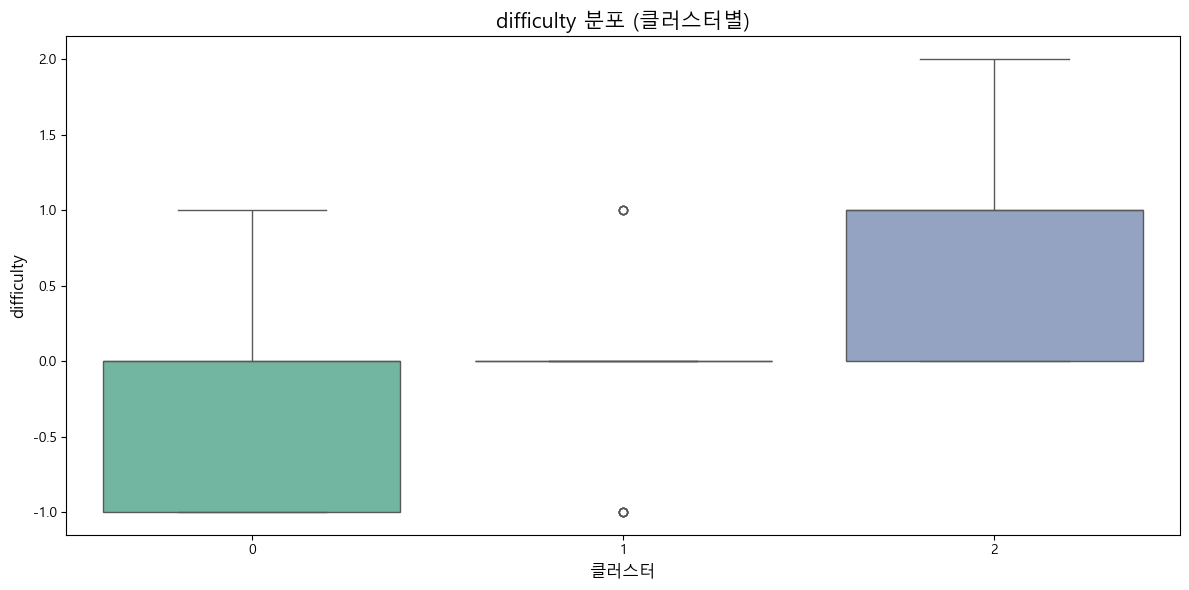

C:\Users\syc09\AppData\Local\Temp\ipykernel_25864\2862513024.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=X_final, x='cluster', y=col, palette='Set2')


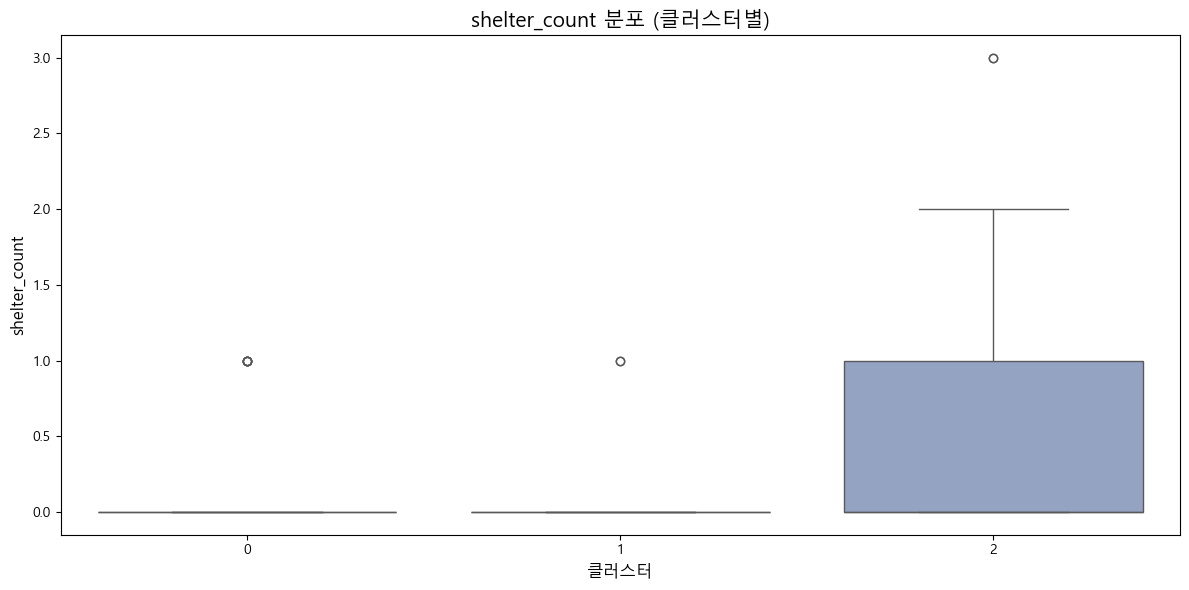

C:\Users\syc09\AppData\Local\Temp\ipykernel_25864\2862513024.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=X_final, x='cluster', y=col, palette='Set2')


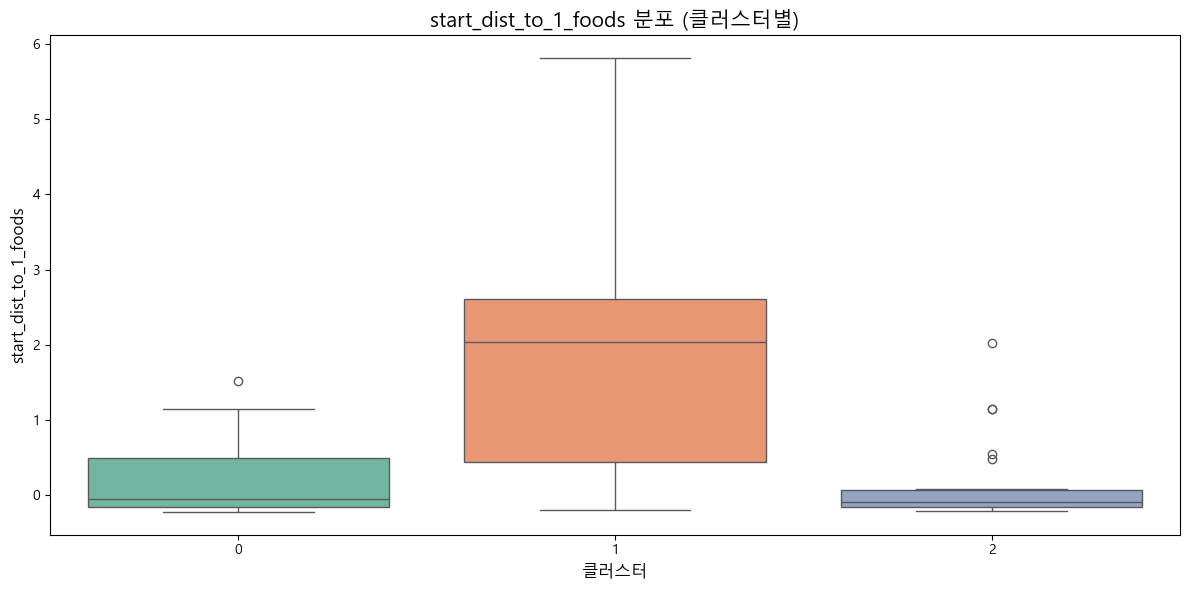

C:\Users\syc09\AppData\Local\Temp\ipykernel_25864\2862513024.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=X_final, x='cluster', y=col, palette='Set2')


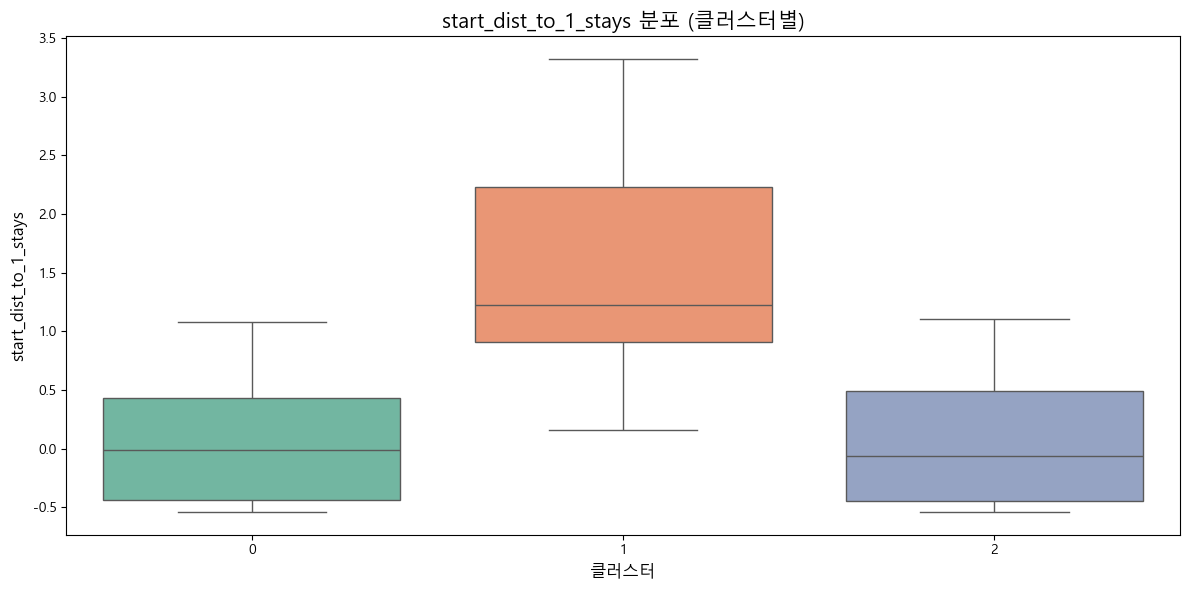

C:\Users\syc09\AppData\Local\Temp\ipykernel_25864\2862513024.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=X_final, x='cluster', y=col, palette='Set2')


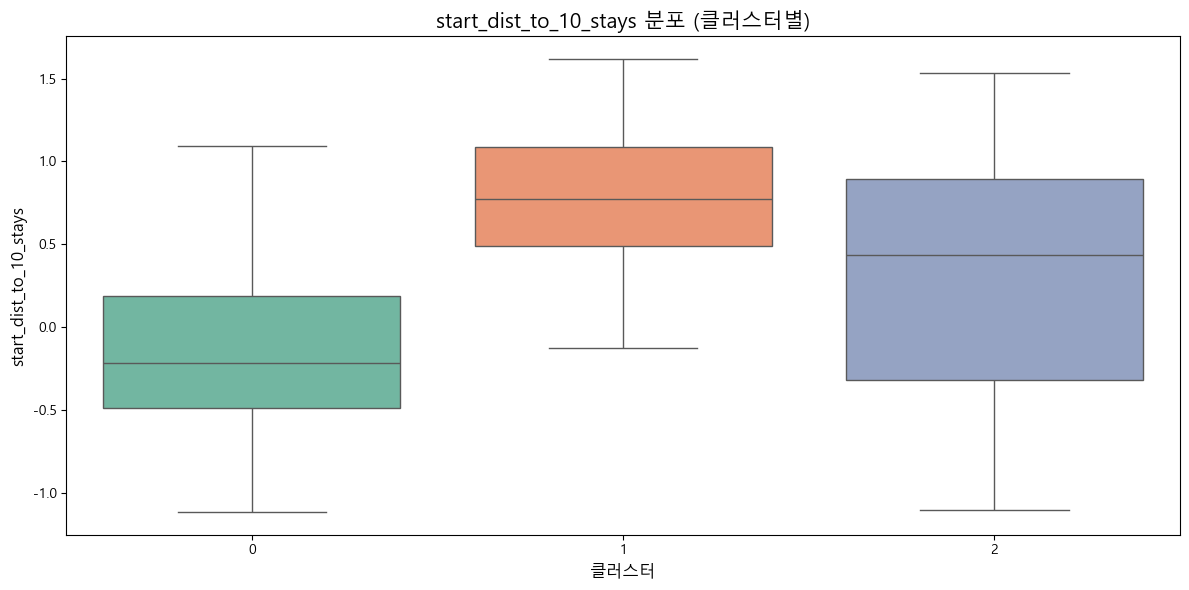

C:\Users\syc09\AppData\Local\Temp\ipykernel_25864\2862513024.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=X_final, x='cluster', y=col, palette='Set2')


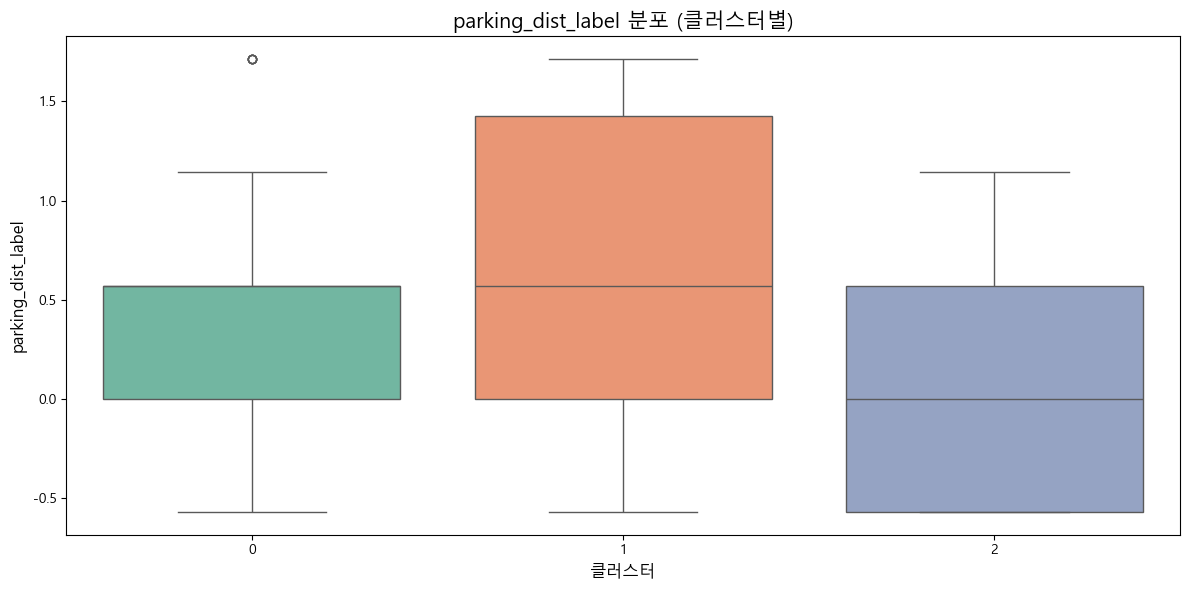

C:\Users\syc09\AppData\Local\Temp\ipykernel_25864\2862513024.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=X_final, x='cluster', y=col, palette='Set2')


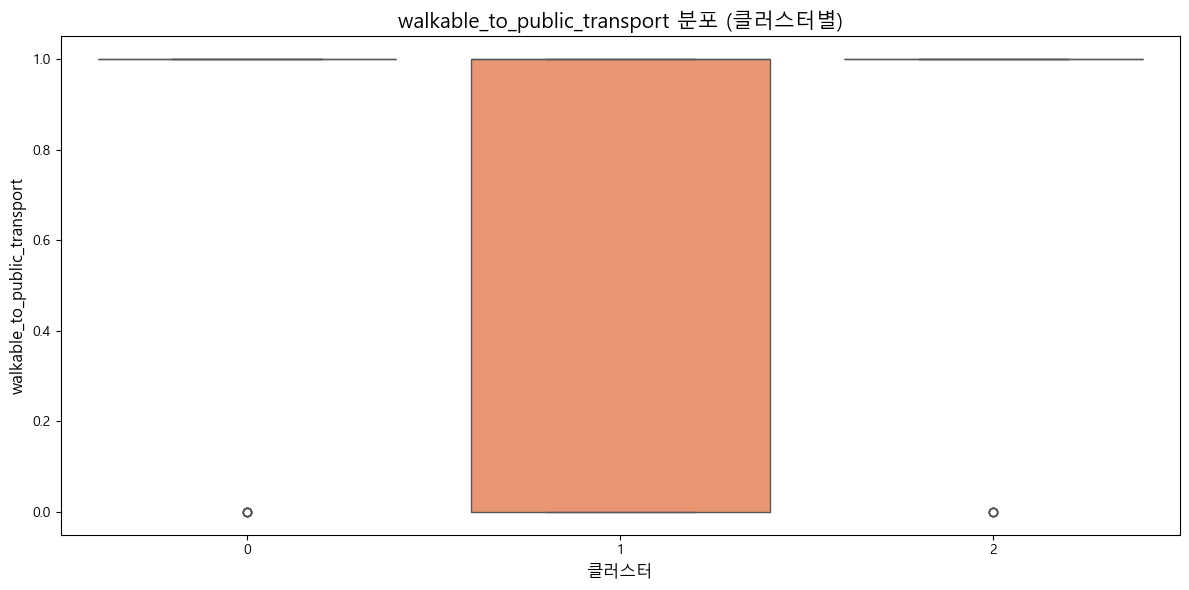

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# 'cluster'를 제외한 모든 컬럼에 대해 반복
features = [col for col in X_final.columns if col != 'cluster']

for col in features:
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=X_final, x='cluster', y=col, palette='Set2')
    plt.title(f"{col} 분포 (클러스터별)", fontsize=15)
    plt.xlabel("클러스터", fontsize=12)
    plt.ylabel(col, fontsize=12)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.tight_layout()
    plt.show()